# Matching Analysis
Analyzing the fuzzy matching results.

In [ ]:
import os
import pandas as pd

# set to desired path
matched_path = os.path.join("data", "matched")

if not os.path.isfile(os.path.join(matched_path, "filtered_max.csv")):
    print("Load matched...")
    df = pd.read_csv(os.path.join(matched_path, "full.csv"), sep="\t")
    df = df
    df.youtube_id = df.youtube_id.astype("category")
    df.clique_id = df.clique_id.astype("category")
    df.youtube_attr = df.youtube_attr.astype("category")
    df.discogs_attr = df.discogs_attr.astype("category")
    print("Group...")
    grouped = (
    df.groupby(["youtube_id", "clique_id", "youtube_attr", "discogs_attr"], sort=False, observed=True)["Score"]
      .max()
    ).to_frame()
    grouped.to_csv(os.path.join(matched_path, "filtered_max.csv"), sep="\t")
else:
    print("Load matched grouped...")
    grouped = pd.read_csv(os.path.join(matched_path, "filtered_max.csv"), sep="\t")
    df = pd.read_csv(os.path.join(matched_path, "full.csv"), sep="\t")


Load matched...
Group...


## Distributions per attribute combination

In [2]:
df_temp = grouped.copy()
df_temp = df_temp.reset_index()
df_temp["pair"] = df_temp.youtube_attr.astype("str") + " to " + df_temp.discogs_attr.astype("str")
df_temp["pair"] = df_temp["pair"].astype("category")


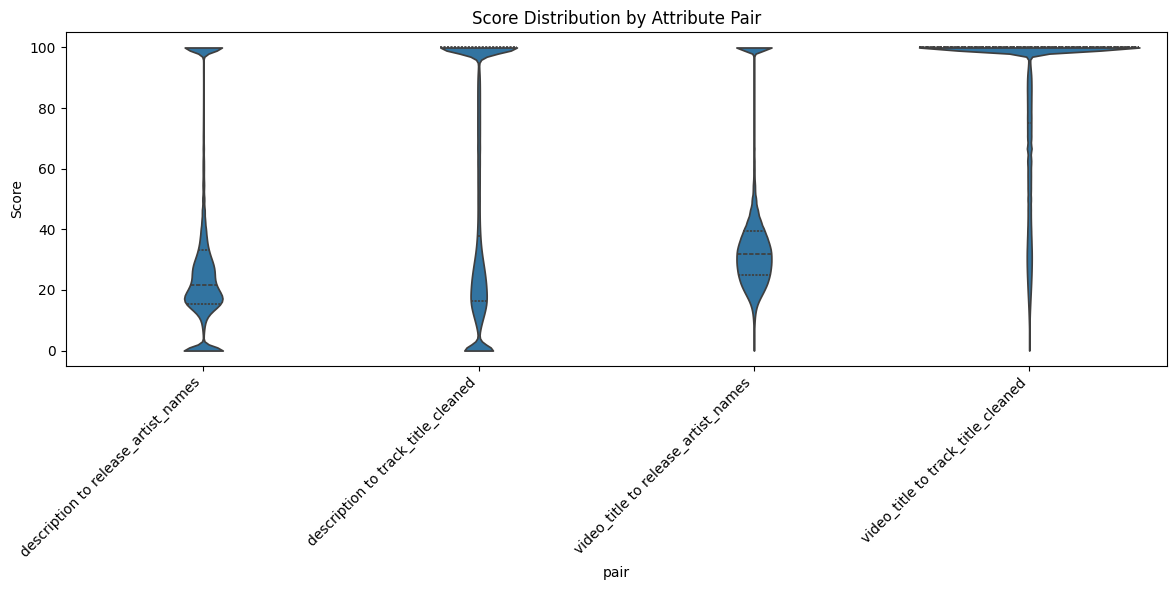

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.violinplot(x="pair", y="Score", data=df_temp, inner="quartile", cut=0)
plt.xticks(rotation=45, ha='right')
plt.title("Score Distribution by Attribute Pair")
plt.tight_layout()
plt.show()


## Sub-Groups
Given a relatively high minimum similarity, we split into the following groups:
- artist + title match
- only title match
- only artist match
- nothing matches 

In [4]:
threshold = 80
df_temp = grouped.copy()
df_temp["Matched"] = df_temp["Score"] > threshold
df_temp = df_temp.reset_index()

pivot = df_temp.pivot_table(
    index=["youtube_id", "clique_id"],
    columns="discogs_attr",
    values="Matched",
    aggfunc="any",  # True if *any* row for that attr is matched
    fill_value=False,
    observed=True
)

def classify_match(row):
    artist = row.get("release_artist_names", False)
    title = row.get("track_title_cleaned", False)
    
    if artist and title:
        return "both"
    elif artist:
        return "only_release_artist_names"
    elif title:
        return "only_track_title_cleaned"
    else:
        return "none"

pivot["match_type"] = pivot.apply(classify_match, axis=1)
pivot.to_csv(os.path.join(matched_path, "filtered_types.csv"), sep="\t")

counts = pivot["match_type"].value_counts().reset_index()
counts['count'] = counts['count'].apply(lambda x: f"{x:,}")
print(counts)


                  match_type      count
0   only_track_title_cleaned  4,192,056
1                       none  1,796,765
2                       both  1,298,169
3  only_release_artist_names     89,220


## Get Sample for manuall annotation

In [5]:
sample = pivot.groupby("match_type").sample(100, random_state=42)

sample = pd.merge(
    sample.reset_index(),
    df,
    on=["youtube_id", "clique_id"],
    how="left"
)
sample = sample.drop(columns=["youtube_attr", "Score"])
sample = sample.drop_duplicates()

discogs_attr_values = sample['discogs_attr'].unique().tolist()
group_cols = [col for col in sample.columns if col not in ['discogs_attr', 'discogs_text'] + discogs_attr_values]

# Pivot and aggregate
sample = sample.pivot_table(
    index=group_cols,
    columns='discogs_attr',
    values='discogs_text',
    aggfunc=lambda x: list(x),
    observed=True,
).reset_index()

sample.columns.name = None
sample.track_title_cleaned = sample.track_title_cleaned.apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
sample = sample.sort_values(by=["match_type"])
sample.to_csv(os.path.join(matched_path, "filtered_sample.csv"), sep="\t", index=False)
sample


,youtube_id,clique_id,match_type,release_artist_names,track_title_cleaned
236,_2rQ80zSvvQ,C-0091715_0,both,"[Sandy Nelson, The Spotnicks, Kingston Trio]",tijuana jail
325,mSXL7Uuqd3M,C-0117291_0,both,"[Gilles Sala, Henri Salvador]",ma doudou
94,ClYjCWBr5VY,C-0111085_0,both,"[Jerry Lee Lewis, Eddy Arnold]",im throwing rice
285,gQW87VU__Pc,C-0150057_0,both,"[Jason Owen, John Denver]",some days are diamonds
91,CQ6hyzzJa30,C-0067652_0,both,"[Estrads Elitorkester, Lena Horne, Phil Moore ...",blue prelude
...,...,...,...,...,...
107,ElIWyvgEz2M,C-0348786_0,only_track_title_cleaned,[Lorena Chaves],monocromia
109,EregOJ-HM9g,C-0110735_0,only_track_title_cleaned,"[Billie Holiday, Teddy Wilson And His Orchestr...",sunbonnet blue
110,Eu-88eCAtHU,C-0057256_1,only_track_title_cleaned,[The Backyard Casanovas],take five
267,dTadlUn3ZC0,C-0088528_0,only_track_title_cleaned,"[Maybelle Carter, The Carter Sisters, The Osbo...",fair and tender ladies
